<a href="https://colab.research.google.com/github/edoardochiarotti/class_datascience/blob/main/2024/03_EDA-Visualization/03_EDA_Practice_Solutions.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# PACKAGES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

# EDA Practice

<img src='https://miro.medium.com/v2/resize:fit:750/format:webp/1*bNSd-pm4XjkOV7uSTNAfnA.jpeg' width="450">

Source: [EDA, Data Preprocessing, Feature Engineering: We are different!](https://medium.com/@ndleah/eda-data-preprocessing-feature-engineering-we-are-different-d2a5fa09f527), Leah Nguyen

## Content

>  More than anything, EDA is a state of mind ([Grolemund & Wickham, 2016](https://r4ds.had.co.nz/exploratory-data-analysis.html))

Exploratory Data Analysis (EDA) is the very first step before developing a statistical or ML model to answer business problems. Our goal is to get acquainted with the important traits of our data set by using descriptive statistics and visualization tools. To learn more about descriptive statistics, graphs and graph libraries in Python, you should read the notebook "03_EDA_Data-visualization". 

In this notebook, we will explore some indicators from [The Quality of Government Environmental Indicators Dataset](https://www.gu.se/en/quality-government/qog-data/data-downloads/environmental-indicators-dataset). Instead on importing the raw data, we will pick it up from where we left off in our previous practice on data cleaning, importing the dataset we created in that notebook. 

*Reference: Povitkina, Marina, Natalia Alvarado Pachon & Cem Mert Dalli. 2021. The Quality of Government Environmental Indicators Dataset, version Sep21. University of Gothenburg: The Quality of Government Institute, https://www.gu.se/en/quality-government*

We will apply the [recipe to empirically answer any question quickly](https://medium.com/towards-data-science/a-recipe-to-empirically-answer-any-question-quickly-22e48c867dd5) by Quentin Gallea, exploring how climate change and consumption patterns affect biodiversity, and more precisely, fishing biocapacity. We will follow these steps:

- [Select our ingredients](#select-ingredients)
- [Pick the right quantity of each ingredient](#pick-ingredients)
- [Tasting and preparing the ingredients (univariate analysis)](#taste-ingredients)
- [Cooking the ingredients together (bivariate analysis)](#cooking-ingredients)
- [Tasting the new recipe](#tasting-ingredients)



**We imported packages at the top of this notebook, do not forget to run the top cell to import the necessary packages!** Feel free to import other libraries if needed.


## Select our ingredients <a name="select-ingredients"></a>

<img src='https://i.imgflip.com/815iqf.jpg' width="500">


Let's import the CSV file "df_qog_polity", obtained from our last practice.

In [2]:
url = 'https://raw.githubusercontent.com/thurmboris/Data-Science_4_Sustainability/main/data/df_qog_polity.csv'
df = pd.read_csv(url)

Our first step is to select our ingredients, i.e., the variables we are interested in. 

In this notebook we will explore the following question:

*How do sea surface temperature (SST) anomalies affect fishing ground biocapacity?*

We could think that SST anomalies is reducing the biosphere's ability to produce seafood. Indeed, since most marine animals live in the upper layers of the water body, excess temperature could diminish the livability of these layers, forcing fishes to migrate, for example, to deeper zones, in turn affecting their ability to reproduce because:
- eggs may properly develop only at given temperature,
- changes in natural characteristics (e.g., terrain) may make breeding impossible, 
- changes in local food chain could make breeding more difficult.

In addition, a high fish consumption could exert additional pressure on the biosphere, while more stringent environmental regulation could lower this pressure. Hence we should also consider these factors in our analysis. 

Is our assumption correct? Let's explore! 

Here are the variables that we selected to answer our research question:
- **outcome variable**: Fishing ground biocapacity per capita (ef_fg_bc), which is the ability of a biosphere to produce seafood (the amount of fishing grounds available, weighted by the productivity of fishing grounds) per capita;
- **main explanatory variable**: SST anomalies (ohi_csst), which is the number of positive temperature deviations (anomalies) that exceed the natural range of variation for a given location, i.e., the frequency with which a location experiences unnaturally warm temperature;
- **additional explanatory variable**: Fish footprint of consumption (gha per person) (ef_fg), calculated based on estimates of the maximum sustainable catch for a variety of fish species.
- **additional explanatory variable**:  Number of climate change laws and policies (ccl_nlp), which is the cumulative sum of laws (legislative acts) and policies (executive provisions) related to climate change

You can learn more about these variables in the [QoG codebook](https://www.qogdata.pol.gu.se/data/codebook_ei_sept21_august2023.pdf). 

Ok, let's extract these variables:

- Extract in a new dataframe the columns 'iso3', 'year', 'cname_qog', 'ef_fg_bc', 'ohi_csst', 'ef_fg', and 'ccl_nlp'.
- Rename the column 'cname_qog' as 'country'
- Display your dataframe

In [3]:
# Your code here...
df_fish = df.loc[:,['iso3', 'year', 'cname_qog', 'ef_fg_bc', 'ohi_csst', 'ef_fg', 'ccl_nlp']]
df_fish = df_fish.rename(columns={'cname_qog': 'country'})
df_fish

,iso3,year,country,ef_fg_bc,ohi_csst,ef_fg,ccl_nlp
0,AFG,1946,Afghanistan,NaN,NaN,NaN,NaN
1,AFG,1947,Afghanistan,NaN,NaN,NaN,NaN
2,AFG,1948,Afghanistan,NaN,NaN,NaN,NaN
3,AFG,1949,Afghanistan,NaN,NaN,NaN,NaN
4,AFG,1950,Afghanistan,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
11717,VDR,1972,"Vietnam, South",NaN,NaN,NaN,NaN
11718,VDR,1973,"Vietnam, South",NaN,NaN,NaN,NaN
11719,VDR,1974,"Vietnam, South",NaN,NaN,NaN,NaN
11720,VDR,1975,"Vietnam, South",NaN,NaN,NaN,NaN


## Pick the right quantity of each ingredient <a name="pick-ingredients"></a>

<img src='https://i.imgflip.com/81615v.jpg' width="400">

Our objective is to explore the data availability of our variables and select a clean sample for the analysis.

- First, use the `.describe()` method ([Documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)) to generate descriptive statistics of our variables
- What do you notice regarding the number of observations?

In [4]:
# Your code here...
df_fish.describe()

,year,ef_fg_bc,ohi_csst,ef_fg,ccl_nlp
count,11722.000000,6201.000000,148.000000,6201.000000,4044.000000
mean,1988.188193,0.626597,0.301236,0.140960,5.394906
std,20.252364,1.487357,0.163395,0.373979,5.462809
min,1946.000000,0.000000,0.000000,0.000000,1.000000
25%,1972.000000,0.042377,0.193787,0.016394,2.000000
50%,1990.000000,0.124728,0.266124,0.049547,3.000000
75%,2005.000000,0.425291,0.348327,0.135210,7.000000
max,2020.000000,17.227063,0.757147,5.596642,48.000000


Although we have 11'722 observations overall, we only have 148 non missing SST anomalies values, and 6'201 non missing ecological footprint values. Let's try to better understand where those missing values are coming from.

- Create a new dataframe grouping the observations by year and counting the number of non missing values for the variables 'ef_fg_bc', 'ohi_csst', and 'ef_fg'. You can use the methods `.groupby()` ([Documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html)) and `.count()` ([Documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.count.html))
- In this new dataframe, remove the rows that have zero non missing observations for our 3 variables
- Display your new dataframe, what do you observe?

In [5]:
# Your code here...
df_fish_counts = df_fish.groupby('year').count().loc[:, ['ef_fg_bc', 'ohi_csst', 'ef_fg']]
df_fish_counts = df_fish_counts.loc[(df_fish_counts != 0).any(axis=1)]
df_fish_counts

,ef_fg_bc,ohi_csst,ef_fg
year,,,
1961,76,0,76
1962,76,0,77
1963,80,0,80
1964,82,0,82
1965,85,0,85
1966,87,0,87
1967,90,0,90
1968,90,0,90
1969,90,0,90


Unfortunately, we only have SST anomalies for the year 2015... It will significantly limit our analysis as it prevents to exploit the time dimension. For the ecological footprint variables, our number of observations is increasing through time. To have a relatively constant sample size, we will restrict to years from 1993 to 2015. We will also only keep countries for which we have observations for our outcome variable, namely fishing ground biocapacity per capita:

- Create a new dataframe keeping only the observations between 1993 to 2015 and for which the variable 'ef_fg_bc' is not missing

In [6]:
# Your code here...
df_s = df_fish[(df_fish['year'] >= 1993) & (df_fish['year'] <= 2015) & ~df_fish['ef_fg_bc'].isnull()].reset_index(drop=True)
df_s

,iso3,year,country,ef_fg_bc,ohi_csst,ef_fg,ccl_nlp
0,AFG,1993,Afghanistan,0.000000,NaN,0.000124,NaN
1,AFG,1994,Afghanistan,0.000000,NaN,0.000126,NaN
2,AFG,1995,Afghanistan,0.000000,NaN,0.000120,NaN
3,AFG,1996,Afghanistan,0.000000,NaN,0.000114,NaN
4,AFG,1997,Afghanistan,0.000000,NaN,0.000107,NaN
...,...,...,...,...,...,...,...
2935,ZMB,2011,Zambia,0.023636,NaN,0.013431,8.0
2936,ZMB,2012,Zambia,0.022913,NaN,0.017987,8.0
2937,ZMB,2013,Zambia,0.022314,NaN,0.024079,8.0
2938,ZMB,2014,Zambia,0.021707,NaN,0.035119,9.0


Let's visualize our geographical coverage!

- Create a new dataframe counting the number of observations for each iso 3 code
- Create an interactive map displaying the number of observations for each country. Do not forget to add a title to your graph. You can also use different [color theme](https://plotly.com/python/builtin-colorscales/). What do you think?

In [7]:
# Your code here...
df_map = df_s.groupby(['iso3']).size().reset_index(name='Number of observations')
fig = px.choropleth(df_map, 
                    locations='iso3',
                    locationmode='ISO-3',
                    color='Number of observations', 
                    hover_name='iso3',
                    title='Number of Observations by Country',
                    color_continuous_scale='Plasma')
fig.show()

We have a nice geographical coverage, covering all continents, and most countries have +20 observations. Cool!

## Tasting and preparing the ingredients (univariate analysis) <a name="taste-ingredients"></a>

<img src='https://i.imgflip.com/81630v.jpg' width="500">

Our objectives are threefold:
- Prepare the data: by studying the distribution of the variables, we will decide if we should transform the data (e.g., log-transform, define a categorical variable, deal with outliers, etc.)
- Choose the right statistical tools: knowing the nature of each variable (continuous, categorical, binary, etc.) will allows us to choose the right statistical tools (correlation, bar/line graphs, scatter plot, etc).
- Get an idea of the underlying variation: looking at how the variable varies over time (line graph) and space (map), will help us better understand the data and potentially spot some anomalies or interesting shocks to exploit for a natural experiment.

Ok, before digging more carefully into each variable, let's have an overview of how our variables are distributed:

- Display descriptive statistics for our selected sample

In [8]:
# Your code here...
df_s.describe()

,year,ef_fg_bc,ohi_csst,ef_fg,ccl_nlp
count,2940.000000,2940.000000,94.000000,2939.000000,1941.000000
mean,2004.075510,0.564536,0.290337,0.121932,4.470376
std,6.624915,1.350069,0.151420,0.246350,4.164377
min,1993.000000,0.000000,0.000000,0.000037,1.000000
25%,1998.000000,0.026004,0.201663,0.018318,2.000000
50%,2004.000000,0.089586,0.262497,0.052246,3.000000
75%,2010.000000,0.338614,0.334437,0.135160,6.000000
max,2015.000000,11.602198,0.732453,3.614244,29.000000


- Create box plots of the variables 'ef_fg_bc', 'ohi_csst', and 'ef_fg'. What do you observe?

*Note: you can create several plots next to each other by using `fig, ax = plt.subplots(1, 3, figsize=(10, 5))`. In `plt.subplots(1,3,figsize=(10,5))`, 1 refers to the number of rows, and 3 to the number of columns: here we would have 3 plots next to each other. You specify the location of each plot thanks to `ax`: here `ax[0]` would be the left plot, `ax[1]` the middle one, and `ax[2]` the right one.*

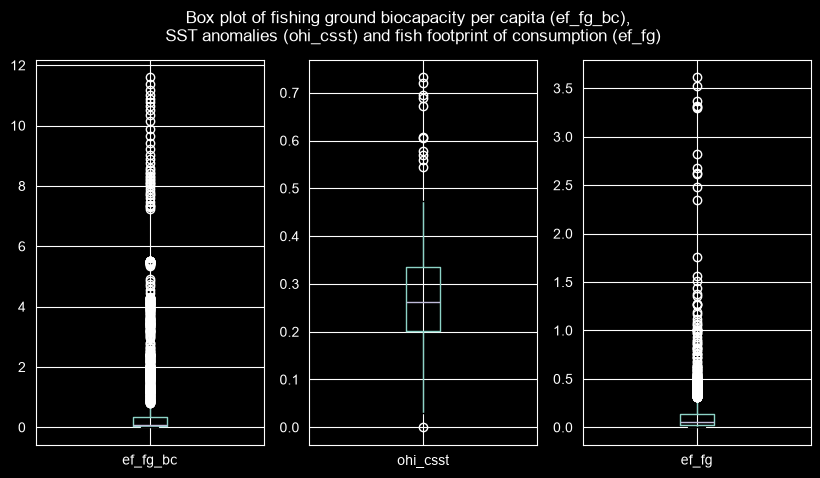

In [9]:
# Your code here...
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
df_s.boxplot('ef_fg_bc', ax=ax[0])
df_s.boxplot('ohi_csst', ax=ax[1])
df_s.boxplot('ef_fg', ax=ax[2])
plt.suptitle('Box plot of fishing ground biocapacity per capita (ef_fg_bc), \n SST anomalies (ohi_csst) and fish footprint of consumption (ef_fg)')
plt.show()

It seems that our ecological footprint variables have a lot of outliers. In other words, they are highly-skewed. Let's continue the exploration.

### Fishing ground biocapacity per capita

Let's explore our first variable, namely the fishing ground biocapacity per capita

- Plot a histogram of the column 'ef_fg_bc'

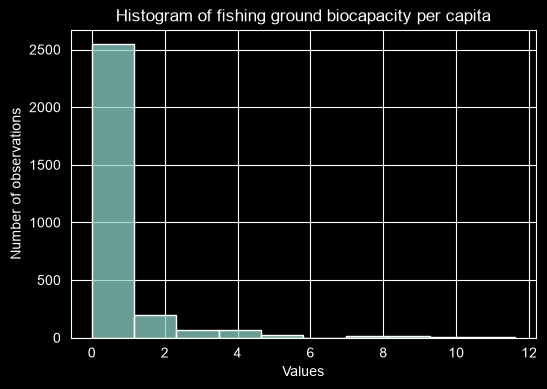

In [10]:
# Your code here
plt.figure(figsize=(6, 4))
sns.histplot(data=df_s, x='ef_fg_bc', bins=10)
plt.title('Histogram of fishing ground biocapacity per capita')
plt.xlabel('Values')
plt.ylabel('Number of observations')
plt.show()

The histogram confirms that our variable is highly skewed.

- Print the skewness of the variable 'ef_fg_bc'

In [11]:
# Your code here...
ef_fg_bc_skewness = df_s['ef_fg_bc'].skew()
print(f'The skewness of the fishing ground biocapacity per capita is: {ef_fg_bc_skewness:0.3f} ')

The skewness of the fishing ground biocapacity per capita is: 4.315 


The skewness is very high. As a rule of thumb, when the skewness is larger than 3, it is a good idea to do a log transformation. However, we have another issue here: it seems that many observations may be equal to zero. To better understand what is happening, let's check for which countries we have values equal to 0.

- Print the countries that have at least one observation equal to zero for the column 'ef_fg_bc'

In [12]:
# Your code here...
ef_fg_bc_zero_countries = list(df_s.loc[df_s['ef_fg_bc'] == 0, 'country'].unique())
print('The countries for which the fishing ground biocapacity per capacity is equal to zero are:', ', '.join(ef_fg_bc_zero_countries))

The countries for which the fishing ground biocapacity per capacity is equal to zero are: Afghanistan, Central African Republic, Lesotho, South Sudan


We could have assumed that the fishing group biocapacity was zero for countries without access to the sea. However, this is not the case (probably because our variable also includes freshwater fishing ground). Hence, the observations equal to zero may simply be missing values. We will remove them, which will simplify our analysis.

- For our "selected sample" dataframe, remove the observations for which 'ef_fg_bc' is equal to zero.
- Display the new descriptive statistics

In [13]:
# Your code here...
df_s = df_s[df_s['ef_fg_bc'] != 0]
df_s.describe()

,year,ef_fg_bc,ohi_csst,ef_fg,ccl_nlp
count,2867.000000,2867.000000,94.000000,2866.000000,1912.000000
mean,2004.064179,0.578910,0.290337,0.124862,4.481695
std,6.619828,1.364107,0.151420,0.248773,4.184354
min,1993.000000,0.000556,0.000000,0.000037,1.000000
25%,1998.000000,0.030388,0.201663,0.021395,2.000000
50%,2004.000000,0.098446,0.262497,0.054359,3.000000
75%,2010.000000,0.346428,0.334437,0.137085,6.000000
max,2015.000000,11.602198,0.732453,3.614244,29.000000


Alright, now we can transform our data.

- Log transform the column 'ef_fg_bc'. You can for instance use the `log` function of the `numpy` library ([Documentation](https://numpy.org/doc/stable/reference/generated/numpy.log.html)), and create a new column 'ef_fg_bc_log' in our dataframe.
- Plot a histogram of your log transformed data
- Check the skewness of your log transformed data

In [14]:
# Your code here...
df_s['ef_fg_bc_log'] = np.log(df_s['ef_fg_bc'])
df_s.describe()

,year,ef_fg_bc,ohi_csst,ef_fg,ccl_nlp,ef_fg_bc_log
count,2867.000000,2867.000000,94.000000,2866.000000,1912.000000,2867.000000
mean,2004.064179,0.578910,0.290337,0.124862,4.481695,-2.280090
std,6.619828,1.364107,0.151420,0.248773,4.184354,2.024552
min,1993.000000,0.000556,0.000000,0.000037,1.000000,-7.494348
25%,1998.000000,0.030388,0.201663,0.021395,2.000000,-3.493713
50%,2004.000000,0.098446,0.262497,0.054359,3.000000,-2.318244
75%,2010.000000,0.346428,0.334437,0.137085,6.000000,-1.060081
max,2015.000000,11.602198,0.732453,3.614244,29.000000,2.451195


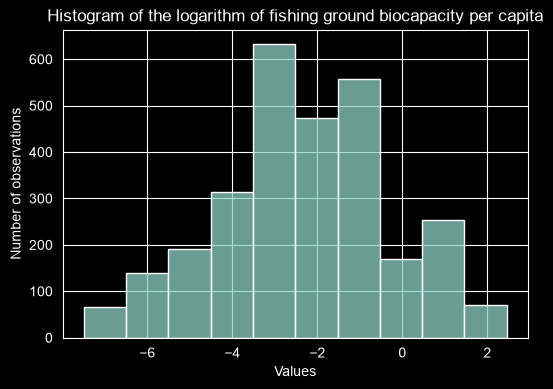

In [15]:
# Your code here
plt.figure(figsize=(6, 4))
sns.histplot(data=df_s, x='ef_fg_bc_log', bins=10)
plt.title('Histogram of the logarithm of fishing ground biocapacity per capita')
plt.xlabel('Values')
plt.ylabel('Number of observations')
plt.show()

In [16]:
# Your code here...
ef_fg_bc_skewness = df_s['ef_fg_bc_log'].skew()
print(f'After log transformation, the skewness of the fishing ground biocapacity per capita is: {ef_fg_bc_skewness:0.3f} ')

After log transformation, the skewness of the fishing ground biocapacity per capita is: -0.136 


Alright, much better! Let's finalize our exploration of the fishing ground biocapacity per capita by checking the geographical patterns and the evolution through time of the variable

- Plot a map of the average 'ef_fg_bc_log' for each country (average of all years). *Note: you can group rows by iso 3 codes, and then use the `.mean()` method*.
- Do you observe any geographical patterns?

In [17]:
# Your code here...
df_map = df_s.groupby('iso3')['ef_fg_bc_log'].mean().reset_index()
fig = px.choropleth(df_map, 
                    locations='iso3',
                    locationmode='ISO-3',
                    color='ef_fg_bc_log', 
                    hover_name='iso3',
                    color_continuous_scale='algae')
fig.update_layout(title={'text': 'Average of fishing ground biocapacity per capita (log transformed)',
                                   'y':0.95,
                                   'x':0.5,
                                   'xanchor': 'center',
                                   'yanchor': 'top'})
fig.show()

- Plot the evolution of the average 'ef_fg_bc_log' (average of all countries). Do not forget labels and title! What do you observe?

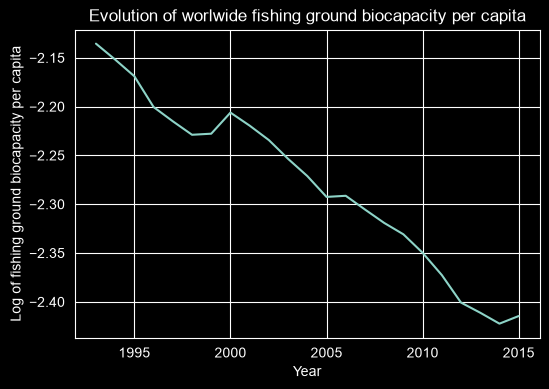

In [18]:
# Your code here...
df_mean_ef_fg_bc = df_s.groupby('year')['ef_fg_bc_log'].mean().reset_index()

plt.figure(figsize=(6, 4))
plt.plot(df_mean_ef_fg_bc['year'], df_mean_ef_fg_bc['ef_fg_bc_log'], linestyle='-')
plt.title('Evolution of worlwide fishing ground biocapacity per capita')
plt.xlabel('Year')
plt.ylabel('Log of fishing ground biocapacity per capita')
plt.show()

### Sea surface temperature (SST) anomalies

Let's now explore our second variable 'ohi_csst'

- Plot a histogram of 'ohi_csst' and check the skewness. Do we need to transform our variable? If yes, transform accordingly, else, continue.
- Plot a map of the SST anomalies in 2015. What do you think? 

*Note: to avoid repeating the same lines of code, it is always a good idea to define functions! We could have done so already in the previous section, but feel free to train how to define functions here, for instance defining a function to create histograms and another one to create a map.*


In [19]:
# Your code here...
def histogram_skewness(df, col, title):
    '''This function plots a histogram of the column "col" of the dataframe "df" 
    and returns the skewness.'''
    # Histogram
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, bins=10)
    plt.title(title)
    plt.xlabel('Values')
    plt.ylabel('Number of observations')
    plt.show()
    # Skewness
    ohi_csst_skewness = df_s[col].skew()
    print(f'The skewness is: {ohi_csst_skewness:0.3f} ')

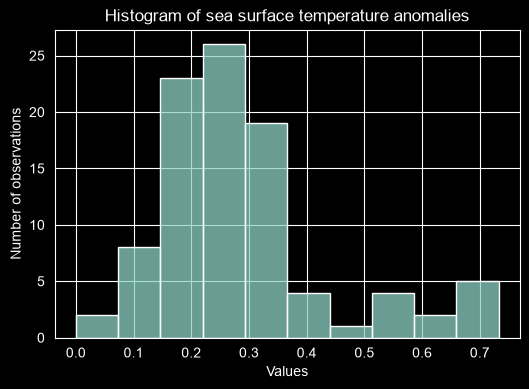

The skewness is: 1.248 


In [22]:
histogram_skewness(df_s, 'ohi_csst', 'Histogram of sea surface temperature anomalies')

In [20]:
def map_countries(df, col, title, color):
    '''This functions plots a map of the average value of column "col" for each country'''
    df_map = df.groupby('iso3')[col].mean().reset_index()
    fig = px.choropleth(df_map, 
                        locations='iso3',
                        locationmode='ISO-3',
                        color=col, 
                        hover_name='iso3',
                        color_continuous_scale=color)
    fig.update_layout(title={'text': title,
                             'y':0.95,
                             'x':0.5,
                             'xanchor': 'center',
                             'yanchor': 'top'})
    fig.show()

In [21]:
map_countries(df_s, 'ohi_csst', 'SST anomalies per country in 2015', 'Reds')

### Fish footprint of consumption

Let's now dive into the fish footprint of consumption.

- Plot a histogram of 'ef_fg' and check the skewness. Do we need to transform our variable? If yes, transform accordingly, else, continue.
- Plot a map of the average fish footprint of consumption per country. What do you observe? 
- Plot the evolution of the average fish footprint of consumption in the world. What do you observe?

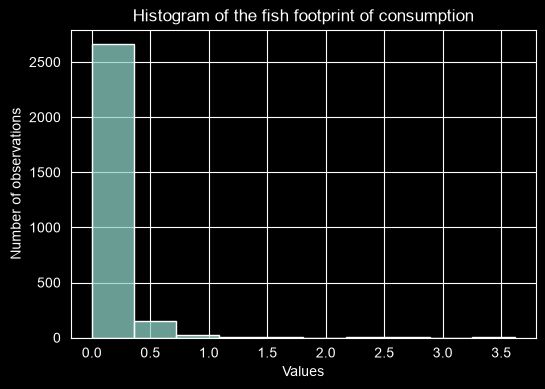

The skewness is: 7.866 


In [23]:
# Your code here...
histogram_skewness(df_s, 'ef_fg', 'Histogram of the fish footprint of consumption')

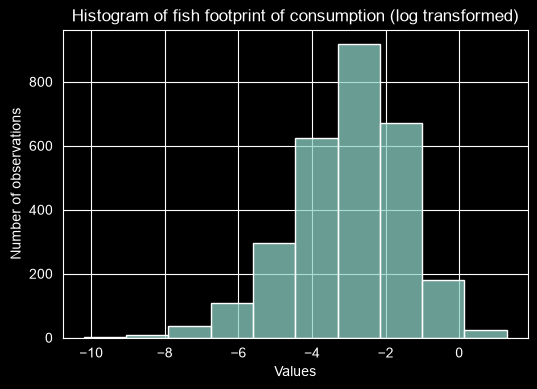

The skewness is: -0.557 


In [24]:
df_s['ef_fg_log'] = np.log(df_s['ef_fg'])
histogram_skewness(df_s, 'ef_fg_log', 'Histogram of fish footprint of consumption (log transformed)')

In [25]:
map_countries(df_s, 'ef_fg_log', 'Average fish footprint of consumption (log transformed) per country', 'Purp')

The fish footprint of consumption seems highly correlated with GDP but also reflects some local diet specificities.

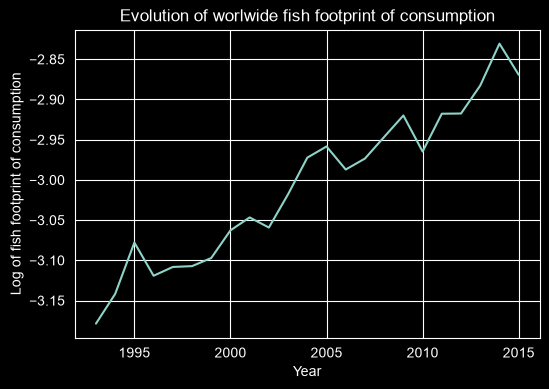

In [26]:
# Your code here...
df_mean_ef_fg = df_s.groupby('year')['ef_fg_log'].mean().reset_index()

plt.figure(figsize=(6, 4))
plt.plot(df_mean_ef_fg['year'], df_mean_ef_fg['ef_fg_log'], linestyle='-')
plt.title('Evolution of worlwide fish footprint of consumption')
plt.xlabel('Year')
plt.ylabel('Log of fish footprint of consumption')
plt.show()

The fish footprint of consumption is increasing, following an opposite trend to the fishing ground biocapacity per capita... We can plot both variables in the same graph to better visualize both trends.

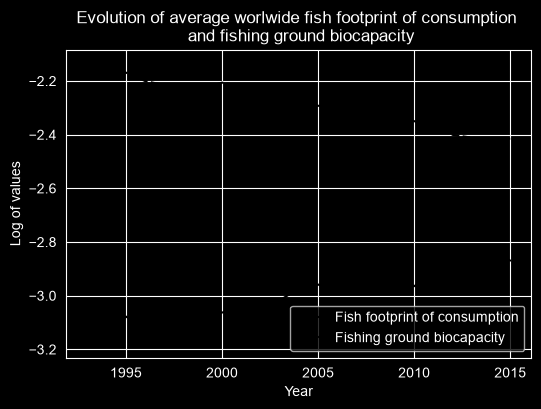

In [27]:
plt.figure(figsize=(6, 4))
plt.plot(df_mean_ef_fg['year'], df_mean_ef_fg['ef_fg_log'], 'k-')
plt.plot(df_mean_ef_fg_bc['year'], df_mean_ef_fg_bc['ef_fg_bc_log'], 'k--')
plt.title('Evolution of average worlwide fish footprint of consumption \n and fishing ground biocapacity')
plt.xlabel('Year')
plt.ylabel('Log of values')
plt.legend(['Fish footprint of consumption','Fishing ground biocapacity'])
plt.show()

### Number of climate change laws and policies

You may have noticed, we did not discuss much the number of climate change regulations until now. Indeed, we should save it in the fridge to keep it fresh and use at the right moment! Joke aside, it is true that we will manipulate and transform this variable later - data science is not a linear process after all. For now, it is important to note that this variable is discrete, not continuous like the other variables. 

- Plot a histogram of 'ccl_nlp'.
- Plot a map of the number of climate change regulations in 2015

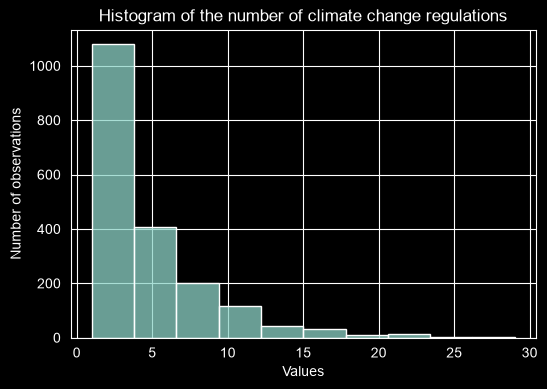

The skewness is: 1.904 


In [28]:
# Your code here...
histogram_skewness(df_s, 'ccl_nlp', 'Histogram of the number of climate change regulations')

In [29]:
df_map = df_s[df_s['year']==2015]
fig = px.choropleth(df_map, 
                    locations='iso3',
                    locationmode='ISO-3',
                    color='ccl_nlp', 
                    hover_name='iso3',
                    color_continuous_scale='Teal')
fig.update_layout(title={'text': 'Number of climate change regulations in 2015',
                                   'y':0.95,
                                   'x':0.5,
                                   'xanchor': 'center',
                                   'yanchor': 'top'})
fig.show()

## Cooking the ingredients together (bivariate analysis) <a name="cooking-ingredients"></a>

<img src='https://i.imgflip.com/1e0h17.jpg' width="400">

Let's now put our ingredients together! Our goal is to detect potential associations between our variables, which will later guide our statistical analysis.

First, remember that for SST anomalies, we only had values for 2015. It is not ideal, and if we were to actually perform a statistical analysis, it would be wise to look for more data (maybe from another database?) or to use another variable (maybe temperature anomalies instead of SST anomalies?). But for now, let's proceed with the data at hand.

- Extract observations for which the variables 'ohi_csst' and 'ccl_nlp' are not missing

In [30]:
# You code here...
df_s_2015 = df_s[(~df_s['ohi_csst'].isnull()) & (~df_s['ccl_nlp'].isnull())].reset_index(drop=True)
df_s_2015

,iso3,year,country,ef_fg_bc,ohi_csst,ef_fg,ccl_nlp,ef_fg_bc_log,ef_fg_log
0,ALB,2015,Albania,0.081207,0.358253,0.037020,2.0,-2.510751,-3.296308
1,AGO,2015,Angola,0.196056,0.231307,0.110688,15.0,-1.629353,-2.201041
2,ARG,2015,Argentina,1.600981,0.192856,0.092827,12.0,0.470616,-2.377020
3,AUS,2015,Australia,3.124566,0.272634,0.110520,17.0,1.139295,-2.202561
4,BHS,2015,Bahamas,8.053516,0.119851,0.114479,4.0,2.086109,-2.167364
...,...,...,...,...,...,...,...,...,...
85,GBR,2015,United Kingdom,0.295563,0.347756,0.078531,17.0,-1.218875,-2.544261
86,TZA,2015,Tanzania,0.054691,0.327664,0.071228,11.0,-2.906048,-2.641863
87,USA,2015,United States,0.331216,0.135769,0.132111,13.0,-1.104984,-2.024112
88,VEN,2015,Venezuela,0.235298,0.473887,0.068755,4.0,-1.446904,-2.677203


We'll first check the correlations between our variables. Even though correlation does not imply causation, it's never a bad idea to check how our variables correlate.

- Display the correlation between the variables 'ef_fg_bc_log' (log transformed), 'ohi_csst', and 'ef_fg_log' (log transformed). *Note: you can use the `pandas` method `.corr()` ([Documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html))*
- For a more visual representation, plot a heat map of your correlation matrix. *Note: you can for instance use the `seaborn` function `heatmap()` ([Documentation](https://seaborn.pydata.org/generated/seaborn.heatmap.html))*

In [31]:
# Your code here...
variables = ['ef_fg_bc_log', 'ohi_csst', 'ef_fg_log']
df_s_2015_corr = df_s_2015[variables].corr()
df_s_2015_corr

,ef_fg_bc_log,ohi_csst,ef_fg_log
ef_fg_bc_log,1.000000,-0.148633,0.397018
ohi_csst,-0.148633,1.000000,-0.194338
ef_fg_log,0.397018,-0.194338,1.000000


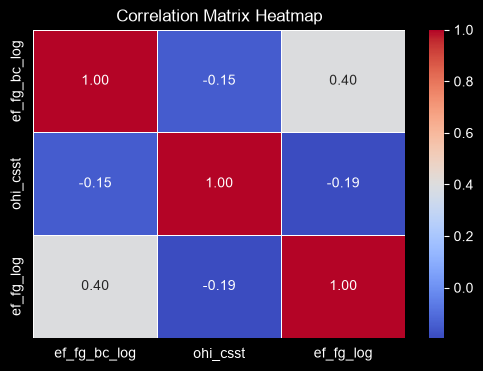

In [32]:
plt.figure(figsize=(6, 4))
sns.heatmap(df_s_2015_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

Note that the absence of (Pearson)-correlation does not indicate an absence of causation. Indeed, there could be a non-linear association between our variables! A scatter plot provides a visual tool to check the relation between our variables.

- Plot two scatter plots:
    - 'ef_fg_bc' (log transformed) vs 'ohi_csst'
    - 'ef_fg_bc' vs 'ef_fg' (both log transformed)
- What do you observe?    

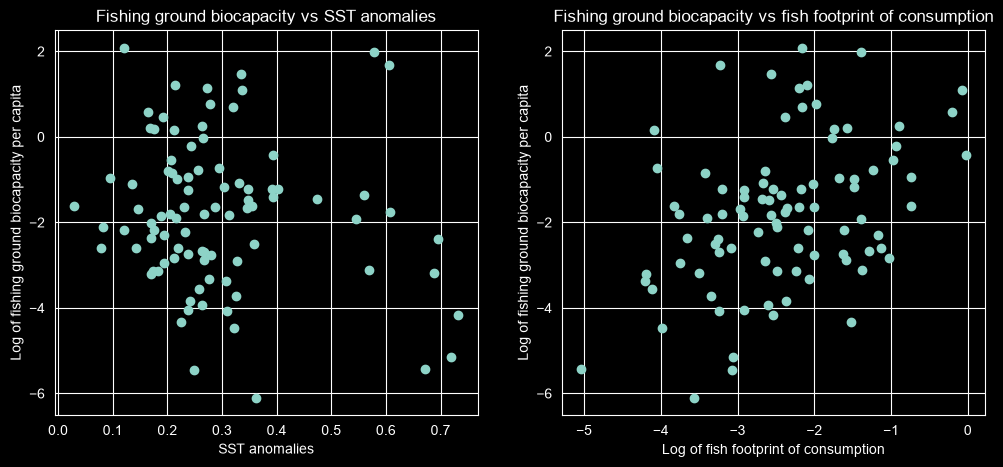

In [34]:
# Your code here...

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot of Fishing ground biocapacity vs SST anomalies
ax[0].scatter(df_s_2015['ohi_csst'], df_s_2015['ef_fg_bc_log']) 
ax[0].set_title('Fishing ground biocapacity vs SST anomalies')
ax[0].set_xlabel('SST anomalies')
ax[0].set_ylabel('Log of fishing ground biocapacity per capita')

# Scatter plot of Fishing ground biocapacity vs fish footprint of consumption
ax[1].scatter(df_s_2015['ef_fg_log'], df_s_2015['ef_fg_bc_log']) 
ax[1].set_title('Fishing ground biocapacity vs fish footprint of consumption')
ax[1].set_xlabel('Log of fish footprint of consumption')
ax[1].set_ylabel('Log of fishing ground biocapacity per capita')

plt.show()

The relation between the fishing ground biocapacity and SST anomalies is not obvious... As for fishing ground biocapacity and fish footprint of consumption, we do have a trend! But wait, it seems that the biocapacity is increasing with the consumption?! When we checked the evolution through time of our variables, they were evolving in the opposite direction, which seemed more in line with our intuition, but here we observe a positive correlation. How is that possible? 

Well it may be an instance of [Simpson's paradox](https://en.wikipedia.org/wiki/Simpson%27s_paradox). This paradox describes phenomena in which a trend appears in several groups of data but disappears or reverses when the groups are combined. Here, it may be a good idea to group our countries by their GDP level and see if there is a relation between our variables within groups of countries. Indeed, richer countries may have both a greater fish consumption and stricter environmental norms protecting fishing biocapacity (what we observe in our scatter plot). However, for the same level of development, a higher fish footprint of consumption could lead to a lower fishing ground biocapacity (what we observe in our previous line plot). 

We did not select GDP as a variable - what a shame, however, we could still do a heterogeneity analysis using... the number of climate change regulations! Yes, it is time to take it out of the fridge! Remember that the number of climate change regulation is a discrete variable. In such case, instead of directly using the variable, it may be interesting to create clusters, e.g., countries with value above the median vs countries with value below the mean.

- Create a new column 'cluster' with values 0 for countries with 'ccl_nlp' below the median, and 1 for countries with 'ccl_nlp' above the median

In [35]:
# Your code here...
ccl_nlp_median = df_s_2015['ccl_nlp'].median()
df_s_2015['cluster'] = (df_s_2015['ccl_nlp'] > ccl_nlp_median).astype(int)
df_s_2015

,iso3,year,country,ef_fg_bc,ohi_csst,ef_fg,ccl_nlp,ef_fg_bc_log,ef_fg_log,cluster
0,ALB,2015,Albania,0.081207,0.358253,0.037020,2.0,-2.510751,-3.296308,0
1,AGO,2015,Angola,0.196056,0.231307,0.110688,15.0,-1.629353,-2.201041,1
2,ARG,2015,Argentina,1.600981,0.192856,0.092827,12.0,0.470616,-2.377020,1
3,AUS,2015,Australia,3.124566,0.272634,0.110520,17.0,1.139295,-2.202561,1
4,BHS,2015,Bahamas,8.053516,0.119851,0.114479,4.0,2.086109,-2.167364,0
...,...,...,...,...,...,...,...,...,...,...
85,GBR,2015,United Kingdom,0.295563,0.347756,0.078531,17.0,-1.218875,-2.544261,1
86,TZA,2015,Tanzania,0.054691,0.327664,0.071228,11.0,-2.906048,-2.641863,1
87,USA,2015,United States,0.331216,0.135769,0.132111,13.0,-1.104984,-2.024112,1
88,VEN,2015,Venezuela,0.235298,0.473887,0.068755,4.0,-1.446904,-2.677203,0


Ok, let's see how grouping our countries by clusters depending on their number of policies affect the relationship between our variables:

- Create a scatter plot of 'ef_fg_bc_log' vs 'ef_fg_log', colored by the country 'cluster'. What do you observe?

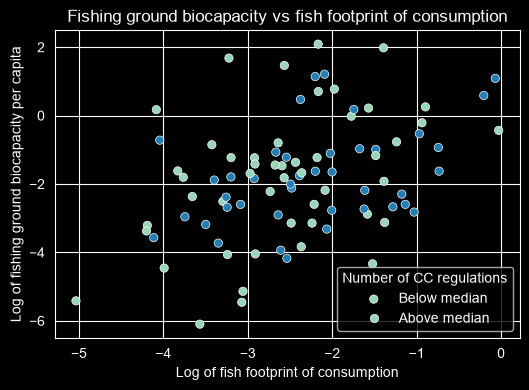

In [36]:
# Your code here...

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_s_2015, x='ef_fg_log', y='ef_fg_bc_log', hue='cluster', palette='YlGnBu')
plt.legend(title='Number of CC regulations', labels=['Below median', 'Above median'])
plt.xlabel('Log of fish footprint of consumption')
plt.ylabel('Log of fishing ground biocapacity per capita')
plt.title('Fishing ground biocapacity vs fish footprint of consumption')
plt.show()

Well... It does not seem like we uncovered some secret relationships... That's a pity, but it does not mean we should give up now! As previously discussed, we may need more data, e.g., GDP, temperature anomalies instead of SST anomalies, to take into consideration the time dimension... Hence, now would be a good time to reflect on what we accomplished so far, check again the documentation to make sure we properly understood our variables, and question if our choices were appropriate.

## Tasting the new recipe <a name="tasting-ingredients"></a>

<img src='https://i.postimg.cc/13xSdFjc/naruto-ramen.jpg' width="250">

It is time to reflect on our cooking experience and evaluate if our research question is worth further investigation:
- What did we learn?
- Did we identify some interesting patterns in our data (geographic clusters, sudden change in values)?
- Did we identify some interesting relationships between our variables?
- Would we have all the data we need to pursue?
- What would be problematic for a proper causal analysis? We don't need fancy statistical model yet! Remember Quentin's *First Aid Statistics* to question the causal link between variables: 
    - Is there something else? 
    - Is it the reverse? 
    - Can we extrapolate?

If you completed this notebook, your deserve to enjoy a bowl of ramen while watching Quentin Gallea's Ted Talk on [How to question numbers and prevent manipulation](https://www.youtube.com/watch?v=bD1Jq6YwPk8)...